In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def download_stock_data(ticker,start_date,end_date):
    """
    Downloads stock_data from yahoo finance

    parameters:
    ticker: str, stock ticker symbol
    start_date: str,format 'YYYY-MM-DD'
    end_date: str,format 'YYYY-MM-DD'

    returns:
    pandas DataFrame containing stock data
    """
    stock_data=yf.download(ticker,start=start_date,end=end_date)
    if stock_data.empty:
        raise ValueError("No data found for the given ticker and date range.")
    return stock_data




In [4]:
def calculate_daily_returns(stock_data):
    """
    Calculates daily returns from stock data in percentage

    Parameters:
    stock_data: pandas DataFrame containing stock data

    Returns:
    pandas Series containing daily returns in percentage
    """
    daily_returns=stock_data['Close'].pct_change().dropna()*100
    return daily_returns

In [5]:
def normalize_prices(stock_data):
    """
    Normalizes stock prices to start at 100 for comparison

    Parameters:
    stock_data: pandas DataFrame containing stock_data

    Returns:
    pandas series containing normalized stock prices
    """
    normalized_prices=(stock_data['Close']/stock_data['Close'].iloc[0])*100
    return normalized_prices

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


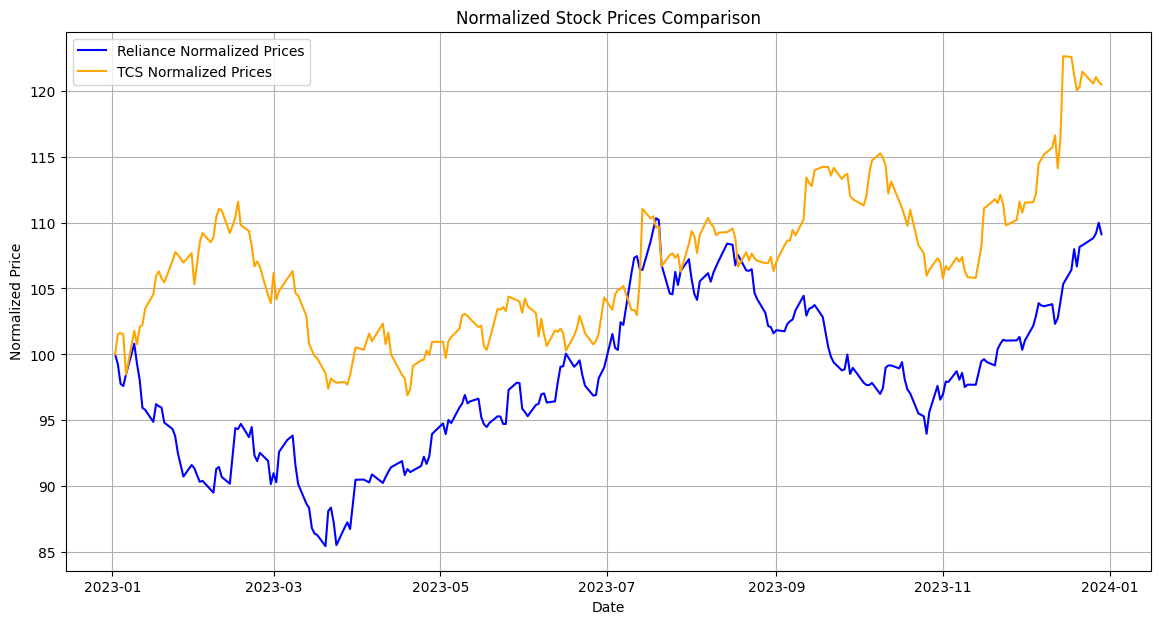

In [ ]:
start_date='2023-01-01'
end_date='2024-01-01'

reliance_data=download_stock_data('RELIANCE.NS',start_date,end_date)
tcs_data=download_stock_data('TCS.NS',start_date,end_date)

# Calculate daily returns
reliance_daily_returns=calculate_daily_returns(reliance_data)
tcs_daily_returns=calculate_daily_returns(tcs_data)

# Normalize Stock Prices 
reliance_normalized=normalize_prices(reliance_data)
tcs_normalized=normalize_prices(tcs_data)

#plotting graphs
plt.figure(figsize=(14,7))
plt.plot(reliance_normalized,label='Reliance Normalized Prices',color='blue')
plt.plot(tcs_normalized,label='TCS Normalized Prices',color='orange')
plt.title('Normalized Stock Prices Comparison')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True)
plt.show()